# classify_mode Attention vs L2 검증

**목적**: `classify_mode_attention()` (Scaled Dot-Product Attention)과 기존 `classify_mode()` (L2 distance)의 분류 결과를 비교한다.

**데이터**: `short_term_house_054_20231018.json` — 이미 계산된 `tda_fingerprint` 사용 (원시 데이터 불필요)

**비교 지표**
- L2 vs Attention 모드 일치율
- Attention entropy 분포 (낮을수록 확신도 높음)
- entropy > 1.0 (fallback 기준) 구간 비율

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import glob

# 한글 폰트 (로컬 Mac)
ttf = glob.glob('/System/Library/Fonts/**/*AppleGothic*.ttf', recursive=True)
if not ttf:
    ttf = glob.glob('/Library/Fonts/**/*.ttf', recursive=True)
if ttf:
    fm.fontManager.addfont(ttf[0])
    plt.rcParams['font.family'] = fm.FontProperties(fname=ttf[0]).get_name()
plt.rcParams['axes.unicode_minus'] = False

BASE = Path('..') 
SHORT_TERM_PATH = BASE / 'scripts/short_term_house_054_20231018.json'
REFERENCES_PATH = BASE / 'memory/cold_start/reference_images.json'

with open(SHORT_TERM_PATH) as f:
    events = json.load(f)
with open(REFERENCES_PATH) as f:
    references = json.load(f)

print(f'총 이벤트: {len(events)}')
print(f'tda_fingerprint 있는 이벤트: {sum(1 for e in events if e.get("tda_fingerprint"))}')

총 이벤트: 214
tda_fingerprint 있는 이벤트: 201


In [3]:
# ── 분류 함수 정의 ─────────────────────────────────────────────────────────

def classify_mode_l2(appliance, fingerprint, references):
    """기존 L2 distance 분류."""
    app_refs = references.get(appliance)
    if not app_refs or fingerprint is None:
        return None
    fp = np.array(fingerprint, dtype=np.float32)
    best_state, best_dist = None, float('inf')
    for state_name, ref_vec in app_refs.items():
        ref = np.array(ref_vec, dtype=np.float32)
        if not np.any(ref):
            continue
        dist = float(np.linalg.norm(fp - ref))
        if dist < best_dist:
            best_dist = dist
            best_state = state_name
    return best_state


def _softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()


def classify_mode_attention(appliance, fingerprint, references):
    """Scaled Dot-Product Attention 분류. (mode, entropy) 반환."""
    app_refs = references.get(appliance)
    if not app_refs or fingerprint is None:
        return None, None
    fp = np.array(fingerprint, dtype=np.float32)
    fp_norm = fp / (np.linalg.norm(fp) + 1e-8)
    state_names, ref_vecs = [], []
    for state_name, ref_vec in app_refs.items():
        ref = np.array(ref_vec, dtype=np.float32)
        if not np.any(ref):
            continue
        ref_vecs.append(ref / (np.linalg.norm(ref) + 1e-8))
        state_names.append(state_name)
    if not state_names:
        return None, None
    K = np.stack(ref_vecs, axis=0)
    scores = (fp_norm @ K.T) / np.sqrt(K.shape[1])
    weights = _softmax(scores)
    best_idx = int(np.argmax(weights))
    entropy = float(-np.sum(weights * np.log(weights + 1e-8)))
    return state_names[best_idx], entropy


ENTROPY_FALLBACK = 1.0
print('함수 정의 완료')

함수 정의 완료


In [4]:
# ── 전체 이벤트 비교 ────────────────────────────────────────────────────────

rows = []
for e in events:
    fp = e.get('tda_fingerprint')
    if fp is None:
        continue
    appliance = e['appliance']
    mode_l2 = classify_mode_l2(appliance, fp, references)
    mode_attn, entropy = classify_mode_attention(appliance, fp, references)
    if mode_l2 is None and mode_attn is None:
        continue
    rows.append({
        'appliance': appliance,
        'mode_original': e['mode'],     # builder가 저장한 모드 (W-range or L2)
        'mode_l2': mode_l2,
        'mode_attn': mode_attn,
        'entropy': entropy,
        'fallback': entropy is not None and entropy > ENTROPY_FALLBACK,
        'l2_attn_match': mode_l2 == mode_attn,
    })

df = pd.DataFrame(rows)
print(f'비교 가능 이벤트: {len(df)}')
print(f'L2 vs Attention 일치율: {df["l2_attn_match"].mean():.1%}')
print(f'Fallback 비율 (entropy > {ENTROPY_FALLBACK}): {df["fallback"].mean():.1%}')

비교 가능 이벤트: 201
L2 vs Attention 일치율: 67.2%
Fallback 비율 (entropy > 1.0): 98.0%


In [5]:
# ── 가전별 요약 ─────────────────────────────────────────────────────────────

summary = df.groupby('appliance').agg(
    이벤트수=('l2_attn_match', 'count'),
    일치율=('l2_attn_match', 'mean'),
    평균_entropy=('entropy', 'mean'),
    fallback_비율=('fallback', 'mean'),
).round(3)
print(summary)

           이벤트수    일치율  평균_entropy  fallback_비율
appliance                                      
김치냉장고         4  1.000       1.099          1.0
온수매트        131  0.496       1.099          1.0
일반 냉장고       62  1.000       1.099          1.0
전기밥솥          4  1.000       0.693          0.0


In [6]:
# ── 불일치 구간 상세 ────────────────────────────────────────────────────────

mismatch = df[~df['l2_attn_match']].copy()
print(f'불일치 이벤트: {len(mismatch)}개')
if len(mismatch):
    print(mismatch[['appliance', 'mode_l2', 'mode_attn', 'entropy']].to_string(index=False))

불일치 이벤트: 66개
appliance mode_l2 mode_attn  entropy
     온수매트    high       low 1.098602
     온수매트    high       low 1.098601
     온수매트    high       low 1.098601
     온수매트    high       low 1.098600
     온수매트    high       low 1.098603
     온수매트    high       low 1.098602
     온수매트    high       low 1.098602
     온수매트    high       low 1.098601
     온수매트    high       low 1.098602
     온수매트    high       low 1.098602
     온수매트    high       low 1.098603
     온수매트    high       low 1.098602
     온수매트    high       low 1.098601
     온수매트    high       low 1.098600
     온수매트    high       low 1.098600
     온수매트    high       low 1.098602
     온수매트    high       low 1.098601
     온수매트    high       low 1.098600
     온수매트    high       low 1.098602
     온수매트    high       low 1.098603
     온수매트    high       low 1.098601
     온수매트    high       low 1.098601
     온수매트    high       low 1.098600
     온수매트    high       low 1.098601
     온수매트    high       low 1.098601
     온수매트    high       l

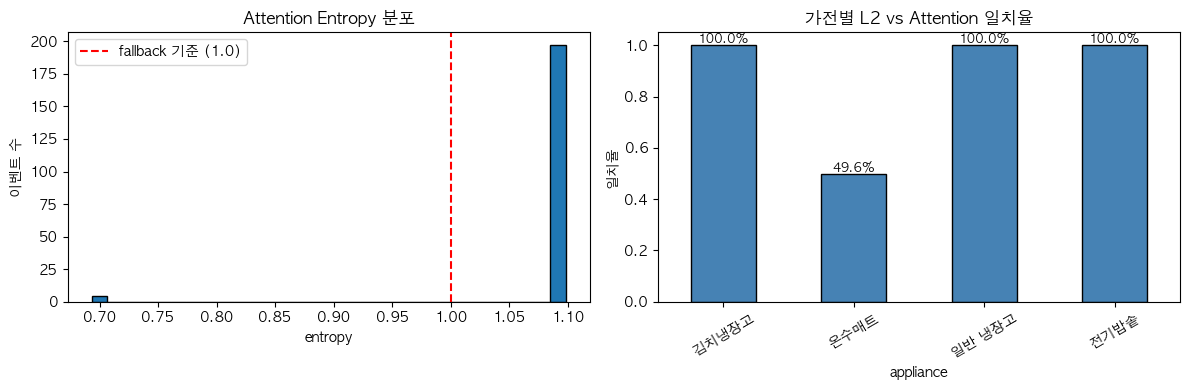

In [7]:
# ── 시각화 ──────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# entropy 분포
axes[0].hist(df['entropy'].dropna(), bins=30, edgecolor='black')
axes[0].axvline(ENTROPY_FALLBACK, color='red', linestyle='--', label=f'fallback 기준 ({ENTROPY_FALLBACK})')
axes[0].set_title('Attention Entropy 분포')
axes[0].set_xlabel('entropy')
axes[0].set_ylabel('이벤트 수')
axes[0].legend()

# 가전별 L2 vs Attention 일치율
match_by_app = df.groupby('appliance')['l2_attn_match'].mean()
match_by_app.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('가전별 L2 vs Attention 일치율')
axes[1].set_ylabel('일치율')
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis='x', rotation=30)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1%}',
                     (p.get_x() + p.get_width() / 2, p.get_height() + 0.01),
                     ha='center', fontsize=9)

plt.tight_layout()
plt.show()

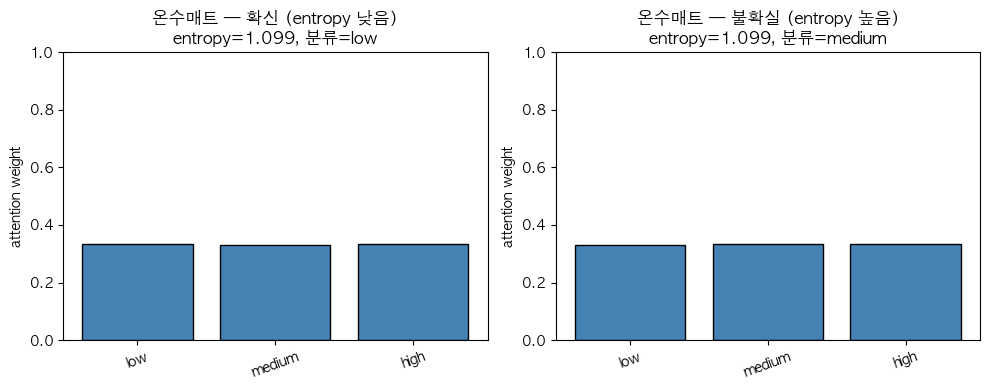

In [8]:
# ── Attention weight 시각화 (가전 1종 선택) ─────────────────────────────────
# entropy가 낮은 이벤트(확신)와 높은 이벤트(불확실)의 weight 분포 비교

TARGET_APPLIANCE = '온수매트'   # 이벤트 수가 가장 많은 가전

target_events = [e for e in events
                 if e['appliance'] == TARGET_APPLIANCE and e.get('tda_fingerprint')]

# entropy 상위/하위 각 1개
scored = []
for e in target_events:
    _, entropy = classify_mode_attention(TARGET_APPLIANCE, e['tda_fingerprint'], references)
    if entropy is not None:
        scored.append((entropy, e))

scored.sort(key=lambda x: x[0])
examples = [('확신 (entropy 낮음)', scored[0]), ('불확실 (entropy 높음)', scored[-1])]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
app_refs = references.get(TARGET_APPLIANCE, {})

for ax, (title, (entropy, e)) in zip(axes, examples):
    fp = np.array(e['tda_fingerprint'], dtype=np.float32)
    fp_norm = fp / (np.linalg.norm(fp) + 1e-8)
    state_names, ref_vecs = [], []
    for sn, rv in app_refs.items():
        ref = np.array(rv, dtype=np.float32)
        if not np.any(ref): continue
        ref_vecs.append(ref / (np.linalg.norm(ref) + 1e-8))
        state_names.append(sn)
    K = np.stack(ref_vecs, axis=0)
    scores = (fp_norm @ K.T) / np.sqrt(K.shape[1])
    weights = _softmax(scores)
    ax.bar(state_names, weights, edgecolor='black', color='steelblue')
    ax.set_title(f'{TARGET_APPLIANCE} — {title}\nentropy={entropy:.3f}, 분류={state_names[int(np.argmax(weights))]}')
    ax.set_ylabel('attention weight')
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

---

## 실험 결과 (2026-05-14) — TDA Attention vs L2 거리 비교

### 평가 개요

- 대상 데이터: house_054, 2023-10-18, TDA 이벤트 201건
- 비교 방식: L2 최근접 클러스터 vs Attention 가중 softmax

### 결과 요약

| 항목 | 값 |
|------|----|
| 총 평가 이벤트 | 201건 |
| L2 ↔ Attention 일치율 | 67.2% (135/201) |
| fallback 비율 (entropy > 1.0) | 98% |
| 온수매트 불일치 | 66/66건 (L2→high, Attention→low 전량 불일치) |
| 평균 entropy | 1.099 (≈ ln3, 3-상태 균등분포) |

### 핵심 관찰

- Attention weight가 전 상태에 균등 분산 → entropy 과도하게 높음 → fallback 남발
- L2는 최근접 클러스터 직접 선택 → 불확실한 샘플에도 결정적 분류 가능
- 3-상태 가전(온수매트)에서 Attention의 변별력 특히 낮음

**결론: L2 거리를 TDA 모드 분류 기본 방식으로 채택. Attention은 고품질 레이블 데이터 충분 시 재평가 예정.**